# **Using the Data Science Life Cycle to Investigate Public Library Usage in the United States**

Spring 2026   

Alexis Shoemaker and Rica Bianca Asuncion

Contributions:  
Alexis Shoemaker - A, B, D, E, G - Worked on identifying a dataset, handled raw data, handled model training, worked on conclusions and insights.

Rica Biana Asuncion - A, C, F, G - Brainstormed dataset ideas, handled data exploration, created the visualizations, created conclusions and insights

## Introduction

Our dataset is looking at Public Libraries in the year 2022. This dataset contains a vast amount of data related to each library in the United States, such as its location, number of visitors, operating budget, and more! We would like to know if the number of librarians, the budget, the size of the population, and the total amount of collection items can predict visits to the libraries. If we can predict the number of visitors, then libraries could use that information to predict how many visitors they would recieve as these variables change.

We also wanted to analyze which library features (such as total collection amounts or programming) are most related to the number of visitors a library recieves. We want to know this as it would help libraries to identify what they may want to focus resources towards in order to drive in visitors.

This is an important investigation because we can learn more about what offerings of a library might relate to the number of visitors recieved. Libraries are wonderful free spaces in which people can gain access to knowledge, resources, or experiences with their communities.

The Data Science Life Cycle is the set of steps that you can follow to understand and analyze data of your choice! Here is a great resource discussing what the Data Science Life Cycle is https://www.datascience-pm.com/data-science-life-cycle/.  


This tutorial will walk you through the Data Science Life Cycle through this library example!

## Data Curation

Source:  https://catalog.data.gov/dataset/public-library-survey-pls-2022

The first step in the data science life cycle is data collection. We are going to use precollected data for this tutorial.

The first step is to download the dataset from https://catalog.data.gov/dataset/public-library-survey-pls-2022. We used the dataset titled PLS_FY22_AE_pud22i to conduct our analysis.

After you've acquired the dataset, you can follow along with the next steps to load the data into your dataframe and prepare the data for analysis!

We suggest creating a jupyter notebook to place the code in as you follow along!



Below are all of the necessary imports you will need to follow along with our project.

In [1397]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import stats, ttest_ind
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

Now, we will load in our downloaded CSV, which is holding all the data collected. We will read this data into our pandas dataframe using the read_csv function and display the first couple rows of the dataframe to get a feel for what the data looks like. A pandas dataframe is like a table that holds our data. Rows represent one entry, so in this case one row represents a single library. Each column represents different features. Examples of columns here would be total number of visitors, or total number of books. Here is some helpful information on the read_csv function: https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html.


In [1398]:
library_df = pd.read_csv("PLS_FY22_AE_pud22i.csv")
library_df.head(5)

,STABR,FSCSKEY,LIBID,LIBNAME,ADDRESS,CITY,ZIP,ZIP4,ADDRES_M,CITY_M,...,GEOSCORE,GEOMTYPE,C19CLOSE,C19PUBSV,C19ECRD2,C19REFER,C19OUTSD,C19XWIF2,C19XWIF3,C19STOTH
0,AK,AK0001,AK0001-002,ANCHOR POINT PUBLIC LIBRARY,34020 NORTH FORK ROAD,ANCHOR POINT,99556,9150,P.O. BOX 129,ANCHOR POINT,...,100.00,POINTADDRESS,M,M,M,N,M,M,M,M
1,AK,AK0002,AK0002-011,ANCHORAGE PUBLIC LIBRARY,3600 DENALI STREET,ANCHORAGE,99503,6055,3600 DENALI STREET,ANCHORAGE,...,100.00,POINTADDRESS,N,Y,N,Y,N,N,Y,N
2,AK,AK0002,AK0002-011,ANCHORAGE PUBLIC LIBRARY,3600 DENALI STREET,ANCHORAGE,99503,6055,3600 DENALI STREET,ANCHORAGE,...,100.00,POINTADDRESS,N,Y,N,Y,N,N,Y,N
3,AK,AK0003,AK0003-002,ANDERSON COMMUNITY LIBRARY,101 FIRST STREET,ANDERSON,99744,M,P.O. BOX 3078,ANDERSON,...,99.62,STREETADDRESS,Y,Y,Y,Y,N,Y,N,Y
4,AK,AK0006,AK0006-002,KUSKOKWIM CONSORTIUM LIBRARY,420 CHIEF EDDIE HOFFMAN HIGHWAY,BETHEL,99559,M,P.O. BOX 368,BETHEL,...,100.00,MANUAL,N,N,N,N,N,N,N,N


Now, we will want to move to the data processing step of the data life cycle. At this step we want to clean up our data to make it relevant for later analysis. This includes things like removing duplicate information or filling in or removing missing values. Here is more infromation on data processing:
 https://www.geeksforgeeks.org/data-analysis/introduction-to-data-processing/


Here is some information on working with pandas dataframes that might be helpful for the rest of this tutorial: https://pandas.pydata.org/pandas-docs/stable/reference/frame.html!


Looking at the displayed information we see that we have some duplicate data in our set. We don't want infromation from one library to count twice, so we will get rid of these duplicates.

In [1399]:
library_df = library_df.drop_duplicates()
library_df.head(5)

,STABR,FSCSKEY,LIBID,LIBNAME,ADDRESS,CITY,ZIP,ZIP4,ADDRES_M,CITY_M,...,GEOSCORE,GEOMTYPE,C19CLOSE,C19PUBSV,C19ECRD2,C19REFER,C19OUTSD,C19XWIF2,C19XWIF3,C19STOTH
0,AK,AK0001,AK0001-002,ANCHOR POINT PUBLIC LIBRARY,34020 NORTH FORK ROAD,ANCHOR POINT,99556,9150,P.O. BOX 129,ANCHOR POINT,...,100.00,POINTADDRESS,M,M,M,N,M,M,M,M
1,AK,AK0002,AK0002-011,ANCHORAGE PUBLIC LIBRARY,3600 DENALI STREET,ANCHORAGE,99503,6055,3600 DENALI STREET,ANCHORAGE,...,100.00,POINTADDRESS,N,Y,N,Y,N,N,Y,N
3,AK,AK0003,AK0003-002,ANDERSON COMMUNITY LIBRARY,101 FIRST STREET,ANDERSON,99744,M,P.O. BOX 3078,ANDERSON,...,99.62,STREETADDRESS,Y,Y,Y,Y,N,Y,N,Y
4,AK,AK0006,AK0006-002,KUSKOKWIM CONSORTIUM LIBRARY,420 CHIEF EDDIE HOFFMAN HIGHWAY,BETHEL,99559,M,P.O. BOX 368,BETHEL,...,100.00,MANUAL,N,N,N,N,N,N,N,N
6,AK,AK0007,AK0007-002,BIG LAKE PUBLIC LIBRARY,3140 SOUTH BIG LAKE ROAD,WASILLA,99623,9663,P.O. BOX 520829,BIG LAKE,...,99.58,POINTADDRESS,Y,Y,Y,Y,Y,N,N,N


Now that we have gotten rid of the duplicates, let's look at the shape of our data. This tells will return a tuple representing the number of rows and columns in our dataset.

In [1400]:
library_df.shape

(9248, 192)

We have 192 columns, which is certainly too many for our analysis. Let's drop some columns that won't be helpful for our analysis.

In [1401]:
columns_to_drop = ['LSABOUND', 'F_POPLSA', 'PHONE', 'OBEREG', 'STATSTRU',
                   'STATNAME', 'STATADDR','LONGITUD', 'LATITUDE', 'CNTYPOP',
                   'CENTRACT','CENBLOCK', 'CDCODE', 'CBSA', 'MICROF', 'GEOSTATUS',
                   'GEOSCORE', 'GEOMTYPE', 'STARTDAT', 'ENDDATE','POPU_UND',
                   'LIBID', 'C_LEGBAS', 'C_ADMIN','GEOCODE', 'CENTLIB', 'BRANLIB',
                   'BKMOB', 'MASTER','LCAP_REV', 'SCAP_REV', 'FCAP_REV', 'OCAP_REV',
                   'CAP_REV', 'LOCGVT', 'STGVT', 'FEDGVT', 'OTHINCM','SALARIES',
                   'BENEFIT', 'STAFFEXP', 'PRMATEXP', 'ELMATEXP', 'OTHMATEX',
                   'OTHOPEXP', 'TOTOPEXP', 'CAPITAL', 'EC_LO_OT', 'ELECCOLL',
                   'REFERENC', 'REFERRPT', 'C19CLOSE', 'C19PUBSV','C19ECRD2',
                   'C19REFER', 'C19OUTSD', 'C19XWIF2', 'C19XWIF3','C19STOTH',
                   'ELMATCIR', 'KIDCIRCL', 'PHYSCIR', 'ELINFO','ELCONT', 'TOTCIR',
                   'OTHPHCIR', 'LOANTO', 'LOANFM','K0_5PRO', 'K6_11PRO', 'YAPRO',
                   'ADULTPRO', 'GENPRO','ONPRO', 'OFFPRO', 'VIRPRO', 'K0_5ATTEN',
                   'K6_11ATTEN','YAATTEN', 'ADULTATTEN', 'GENATTEN', 'ONATTEN',
                   'OFFATTEN','VIRATTEN', 'TOTPRES', 'TOTVIEWS', 'PITUSR', 'PITUSRRPT',
                   'WIFISESS', 'GPTERMS', 'WIFISRPT', 'CNTY', 'ADDRES_M', 'CITY_M',
                   'ZIP_M', 'ZIP4', 'ZIP4_M', 'C_RELATN', 'F_CENLIB', 'F_BRLIB',
                   'F_BKMOB','LSAGEOID', 'LSAGEORATIO', 'LSAGEOTYPE', 'F_SALX',
                   'F_BENX', 'F_TOSTFX', 'F_PRMATX', 'F_ELMATX', 'F_MASTER',
                   'F_LIBRAR', 'OTHPAID', 'F_OTHSTF', 'F_TOTSTF', 'TOTSTAFF',
                   'F_LOCGVT', 'F_STGVT', 'F_FEDGVT', 'F_OTHINC', 'F_TOTINC',
                   'F_AUD_PH', 'F_AUD_DL', 'F_TOTATT', 'F_YAATT', 'F_GPTERM',
                   'F_PITUSR', 'F_WIFISS', 'F_OTMATX', 'F_FCAPRV', 'F_VID_PH',
                   'F_EBOOK', 'F_TCAPRV', 'F_TCAPX', 'F_VISITS', 'F_REFER',
                   'F_PHYSCR', 'F_TOTCIR', 'F_KIDCIR', 'F_EMTCIR', 'F_PHYSCR',
                   'F_ELINFO', 'F_ELCONT', 'F_TOCOLX','F_OTHOPX', 'F_TOTOPX',
                   'F_LCAPRV', 'F_SCAPRV', 'F_OCAPRV','F_LOANTO', 'F_LOANFM',
                   'F_BKVOL', 'F_VID_DL', 'F_EC_L_O','F_EC_ST', 'F_ELECOL', 'F_HRS_OP',
                   'F_REGBOR', 'F_TOTCOL','F_TOTPRO', 'F_YAPRO', 'YR_SUB', 'LOCALE_ADD',
                   'LOCALE_MOD','VISITRPT', 'EC_ST', 'OTHPHYS']
library_df = library_df.drop(axis=1, columns=columns_to_drop)
print(library_df.shape)

(9248, 27)


That's much better! Now that we have the columns that are relevant for our analysis, we can give each column a new label that better describes what they represent. These new labels will be much easier to read during the rest of this tutorial!

In [1402]:
library_df = library_df.rename(columns={'STABR': 'State', 'FSCSKEY': 'Key',
        'ADDRESS' : 'Address', 'CITY' : 'City', 'ZIP': 'Zip Code',
       'LIBNAME': 'Name','C_FSCS' : 'Meets Public Library Definition',
       'POPU_LSA': 'Population of legal service area', 'LIBRARIA': 'Total Librarians',
       'TOTINCM': 'Total Operating Revenue', 'TOTEXPCO': 'Total Amount Spent on Library Collection',
       'BKVOL' : 'Num. of Print Materials', 'EBOOK' : 'Num. of Electronic Books',
       'AUDIO_PH': 'Num. of Physical Audio Materials', 'AUDIO_DL': 'Num. of Downloadable Audio Materials',
       'VIDEO_PH': 'Num. of Physical Video Materials', 'VIDEO_DL': 'Num. of Downloadable Video Materials',
       'TOTPHYS': 'Num. of Total Physical Items in Collection', 'HRS_OPEN':'Hours Open',
       'VISITS': 'Visits', 'REGBOR': 'Registered Users', 'ODFINE': 'Overdue Fine',
       'TOTCOLL': 'Total Collection Use', 'TOTPRO': 'Total Number of Live Programs',
       'TOTATTEN': 'Total Attendence of Live Programs', 'WEBVISIT': 'Num. of Web Visits',
       'RSTATUS': 'Reporting Status'})
library_df.head(5)

,State,Key,Name,Address,City,Zip Code,Meets Public Library Definition,Population of legal service area,Total Librarians,Total Operating Revenue,...,Num. of Total Physical Items in Collection,Hours Open,Visits,Registered Users,Overdue Fine,Total Collection Use,Total Number of Live Programs,Total Attendence of Live Programs,Num. of Web Visits,Reporting Status
0,AK,AK0001,ANCHOR POINT PUBLIC LIBRARY,34020 NORTH FORK ROAD,ANCHOR POINT,99556,Y,2105,0.00,71874,...,23087,1404,5127,1950,M,10406,150,898,0,1
1,AK,AK0002,ANCHORAGE PUBLIC LIBRARY,3600 DENALI STREET,ANCHORAGE,99503,Y,291247,15.00,9357471,...,374660,7596,261807,123846,Y,1119104,758,10749,632473,2
3,AK,AK0003,ANDERSON COMMUNITY LIBRARY,101 FIRST STREET,ANDERSON,99744,Y,177,0.00,13885,...,17177,420,421,138,N,911,-1,-1,-1,4
4,AK,AK0006,KUSKOKWIM CONSORTIUM LIBRARY,420 CHIEF EDDIE HOFFMAN HIGHWAY,BETHEL,99559,Y,6325,1.00,138115,...,41382,2040,12817,2062,N,15153,80,4676,-1,1
6,AK,AK0007,BIG LAKE PUBLIC LIBRARY,3140 SOUTH BIG LAKE ROAD,WASILLA,99623,Y,10066,2.00,417502,...,24926,2356,27063,2867,Y,36934,249,8722,-1,1


We also want to get rid of rows that are missing data. If the data wasn't reported the value was filled in as a negative number. We want to ensure our libraries represent a legal service area, were visited, and were open at all during the data collection period.

In [1403]:
library_df = library_df[(library_df["Visits"] > 0) &
                        (library_df["Population of legal service area"] > 0) &
                        (library_df["Hours Open"] > 0)]
library_df.head(5)

,State,Key,Name,Address,City,Zip Code,Meets Public Library Definition,Population of legal service area,Total Librarians,Total Operating Revenue,...,Num. of Total Physical Items in Collection,Hours Open,Visits,Registered Users,Overdue Fine,Total Collection Use,Total Number of Live Programs,Total Attendence of Live Programs,Num. of Web Visits,Reporting Status
0,AK,AK0001,ANCHOR POINT PUBLIC LIBRARY,34020 NORTH FORK ROAD,ANCHOR POINT,99556,Y,2105,0.00,71874,...,23087,1404,5127,1950,M,10406,150,898,0,1
1,AK,AK0002,ANCHORAGE PUBLIC LIBRARY,3600 DENALI STREET,ANCHORAGE,99503,Y,291247,15.00,9357471,...,374660,7596,261807,123846,Y,1119104,758,10749,632473,2
3,AK,AK0003,ANDERSON COMMUNITY LIBRARY,101 FIRST STREET,ANDERSON,99744,Y,177,0.00,13885,...,17177,420,421,138,N,911,-1,-1,-1,4
4,AK,AK0006,KUSKOKWIM CONSORTIUM LIBRARY,420 CHIEF EDDIE HOFFMAN HIGHWAY,BETHEL,99559,Y,6325,1.00,138115,...,41382,2040,12817,2062,N,15153,80,4676,-1,1
6,AK,AK0007,BIG LAKE PUBLIC LIBRARY,3140 SOUTH BIG LAKE ROAD,WASILLA,99623,Y,10066,2.00,417502,...,24926,2356,27063,2867,Y,36934,249,8722,-1,1


Now that we've cleaned up our dataframe, we can take a closer look at the actual data to start gaining some insights!

## Exploratory Data Analysis

The next step of the data life cycle is exploratory data analysis. At this step we want to examine our dataset to best visualize and understand the data we are working with. This helps us to look at patterns, understand relationships, or even just visualize the data! Here is a great resource for learning more about exploratory data analysis: https://www.geeksforgeeks.org/data-analysis/what-is-exploratory-data-analysis/

Now, we will look for some main characteristics of this data set through some exploratory data analysis techniques!

First, let's take a look at some of the correlations of each variable that can be found in our dataset! We will do this using a [correlation heatmap](https://www.geeksforgeeks.org/python/how-to-create-a-seaborn-correlation-heatmap-in-python/). A heatmap is a visualization technique that helps to display the relationship between two selected variables!

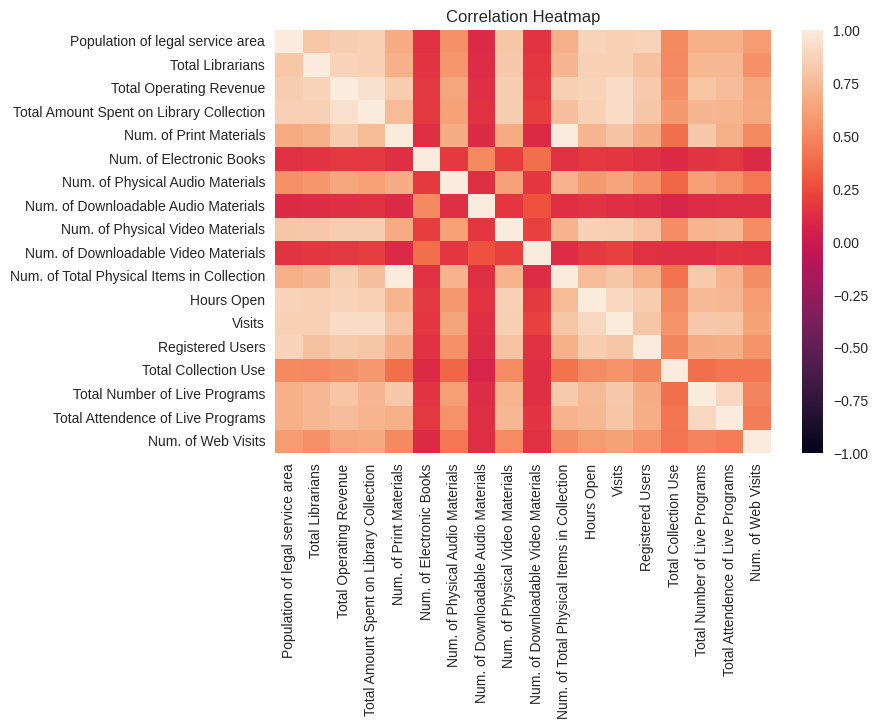

In [1404]:
df = library_df.drop(['Zip Code', 'Reporting Status'], axis=1)
corr_vals = df.corr(numeric_only=True)
sns.heatmap(corr_vals,vmin = -1, vmax = 1)
plt.title("Correlation Heatmap")
plt.show()

This shows the correlation between each of the features in our dataset. Let's take a look at the relationship between the number of website visits and the total collection usage so that we can see if libraries should invest more in their websites. We can analyze the relationship between the number of visits the library website recieves and the total usage of their collection. To do this, we will want to look at libraries that have a website that was utilized.

In [1405]:
corr = library_df[library_df['Num. of Web Visits'] > 0]['Num. of Web Visits'].corr(library_df[library_df['Total Collection Use'] > 0]['Total Collection Use'])
print(corr)

0.41873319906742756


A correlation of 0.4187 means there is a slight postive correlation between the number of website visits and the usage of the library. We will graph the correlation to better understand the relationship.

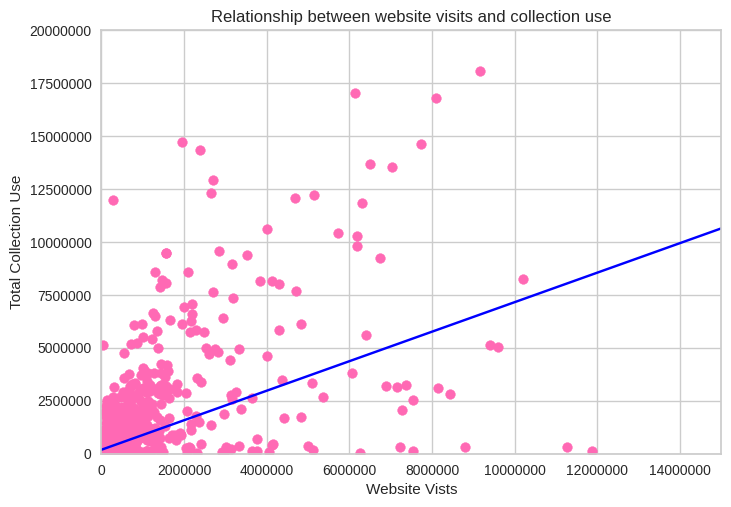

In [1406]:
clean_df = library_df[(library_df['Num. of Web Visits'] > 0) & (library_df['Total Collection Use'] > 0)]
plt.scatter(clean_df['Num. of Web Visits'], clean_df['Total Collection Use'], c="hotpink")
plt.plot(np.unique(clean_df['Num. of Web Visits']),
        np.poly1d(np.polyfit(clean_df['Num. of Web Visits'], clean_df['Total Collection Use'], 1))
        (np.unique(clean_df['Num. of Web Visits'])), color='blue')
plt.xlabel('Website Vists')
plt.ylabel('Total Collection Use')
plt.title("Relationship between website visits and collection use")
plt.ticklabel_format(style='plain')
plt.ylim(bottom=0, top=20000000)
plt.xlim(left=0, right=15000000)
plt.show()


Now we want to look at the relationship between the number of website visits and the number of visits to the actual library location.

In [1407]:
corr = library_df[library_df['Num. of Web Visits'] > 0]['Num. of Web Visits'].corr(library_df[library_df['Visits'] > 0]['Visits'])
print(corr)

0.6349078716414528


The correlation coefficient of .635 means the relationship between the number of website visits and the total location visits seems to have a fairly strong positive relationship.

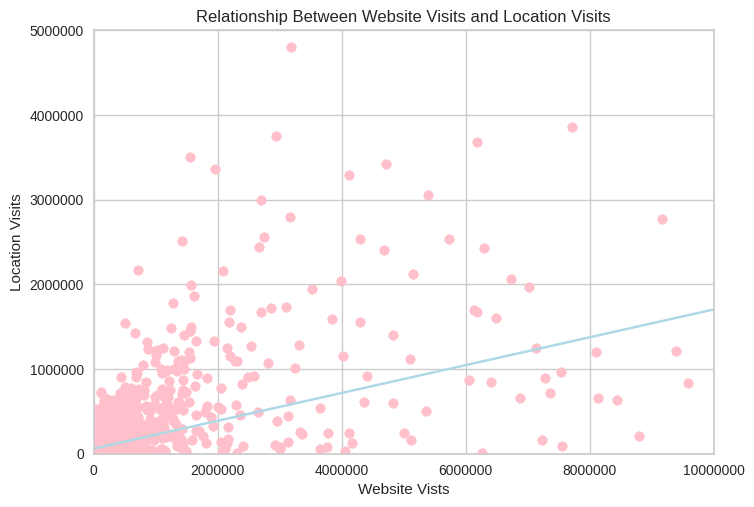

In [1408]:
clean_df = library_df[(library_df['Num. of Web Visits'] > 0) & (library_df['Visits'] > 0)]
plt.scatter(clean_df['Num. of Web Visits'], clean_df['Visits'], c="pink")
plt.plot(np.unique(clean_df['Num. of Web Visits']),
        np.poly1d(np.polyfit(clean_df['Num. of Web Visits'], clean_df['Visits'], 1))
        (np.unique(clean_df['Num. of Web Visits'])), color='lightblue')
plt.xlabel('Website Vists')
plt.ylabel('Location Visits')
plt.title("Relationship Between Website Visits and Location Visits")
plt.ylim(bottom=0, top=5000000)
plt.xlim(left=0, right=10000000)
plt.ticklabel_format(style='plain')

plt.show()


This gives us some neat insights into some correlations between variables in our dataset. Lets now run a hypothesis test.

Hypothesis tests help us to identify whether we have enough evidence to accept or reject a claim we make about our data. You can learn more about what a hypothesis test is here: https://www.geeksforgeeks.org/data-science/understanding-hypothesis-testing/

We want to evaluate if the libraries serving larger populations have a different number of visits per capita compared to libraries who serve smaller populations. We split the libraries into two groups, large population which was classified as over 50,000 served and small population which was classified as less than 50,000 served. Let's identify our null and alternative hypotheses.

- **H0 (Null Hypothesis):** The mean visits per capita is the same for large population libraries and small population libraries.
- **H1 (Alternative Hypothesis):** The mean visits per capita is different between large population and small population libraries.

We will use a two sample t-test to determine whether the difference in visits per capita is statistically significant. We will set our significance level to  0.05.

In [1409]:
library_df['Visits per Capita'] = library_df['Visits'] / library_df['Population of legal service area']

large = library_df[library_df['Population of legal service area'] >= 50_000]['Visits per Capita']
small = library_df[library_df['Population of legal service area'] < 50_000]['Visits per Capita']

t_stat, p_value = ttest_ind(large, small, equal_var=False)

print("t-statistic:", round(t_stat, 4))
print("p-value:", p_value)

t-statistic: -26.5622
p-value: 1.533237141768153e-146


We will reject the null hypothesis as our p-value is much smaller than 0.05.

The box-plot below visualises the full distribution of visits per capita for each group.

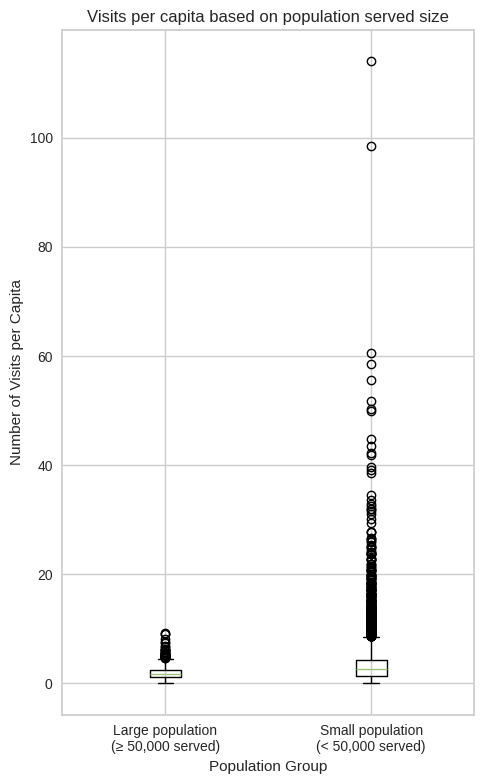

In [1410]:
fig, ax = plt.subplots(figsize=(5, 8))

plt.boxplot([large.values, small.values])
ax.set_xticks([1, 2])
ax.set_xticklabels(['Large population\n(≥ 50,000 served)', 'Small population\n(< 50,000 served)'])

plt.title("Visits per capita based on population served size")
plt.xlabel('Population Group')
plt.ylabel('Number of Visits per Capita')

plt.tight_layout()
plt.show()


Now we will zoom in further on these plots

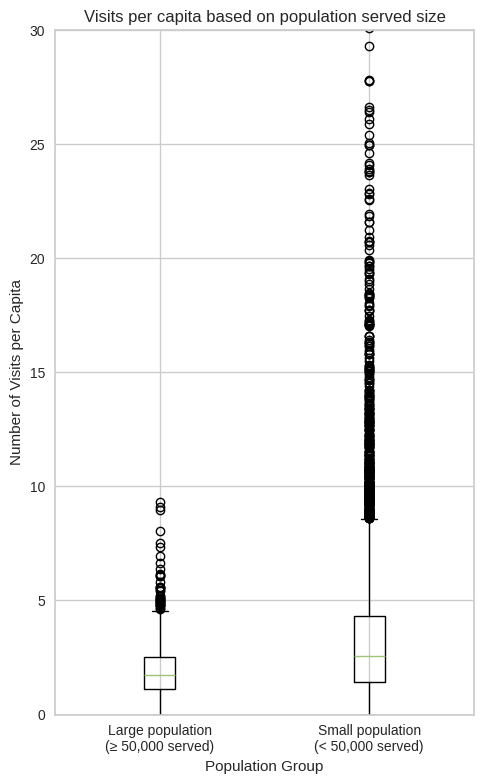

In [1411]:
fig, ax = plt.subplots(figsize=(5, 8))

plt.boxplot([large.values, small.values])
ax.set_xticks([1, 2])
ax.set_xticklabels(['Large population\n(≥ 50,000 served)', 'Small population\n(< 50,000 served)'])

plt.title("Visits per capita based on population served size")
plt.xlabel('Population Group')
plt.ylabel('Number of Visits per Capita')
plt.ylim(bottom=0, top=30)
plt.tight_layout()
plt.show()

Lets run one more test before we do our analysis to get some more insights into how some of our data might be distributed. We won't look at every variable, but we will look at the total operating revenue. This can help us identify how some of our data might be distributed, and if we will need to normalize the data during our machine learning analysis.  

The code below will examine Total Operating Revenue using the mean, median, standard deviation, and skewness.

A large gap between the mean and median values would indicate that our distribution is skewed by outliers.
A high skewness value would suggest that a small number of libraries receive a disproportionately large share of funding.

In [1412]:
posRevenue = library_df[library_df['Total Operating Revenue'] > 0]['Total Operating Revenue']

mean = posRevenue.mean()
median = posRevenue.median()
std = posRevenue.std()
skew = posRevenue.skew()

print("Summary Statistics of Total Operating Revenue")
print("Mean:",mean)
print("Median:", median)
print("Standard Deviation:", std)
print("Skew:", skew)

Summary Statistics of Total Operating Revenue
Mean: 1699552.785307517
Median: 296576.0
Standard Deviation: 7929990.302273209
Skew: 19.47367894603624


Next we will graph our findings to better represent them visually.

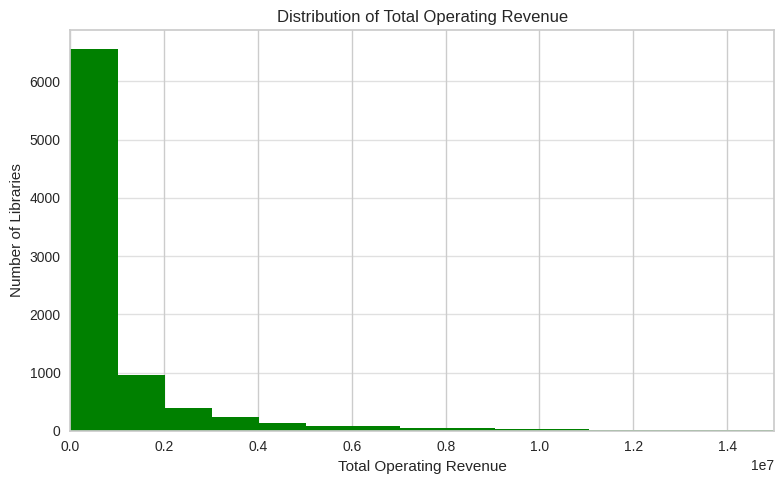

In [1413]:
plt.figure(figsize=(8,5))
plt.hist(library_df['Total Operating Revenue'], bins=350, color='green')
plt.xlabel('Total Operating Revenue')
plt.ylabel('Number of Libraries')
plt.title('Distribution of Total Operating Revenue')
plt.grid(axis='y', linestyle='-', alpha=0.6)
plt.xlim(left=0, right=15000000)
plt.tight_layout()
plt.show()

Here we can see that the distribution of Total Operating Revenue across U.S. public libraries is extremely right-skewed, with a skewness of 19.47 and a mean of 1,699,552.79 that is nearly six times higher than the median of 296,576.00. This large gap between the mean and median reveals that a small number of large, well-funded library systems are pulling the average up significantly, while the majority of libraries operate on much more modest budgets.
This is a great insight to have as it tells us that our data may be skewed, and we may have to take precautions to reduce the effects of outliers later!

## Primary Analysis: Using linear regression to see if we can predict number of visitors

Here, we are going to use the linear regression model to see if there are characteristics of the library, such as the number of librarians, number of items in their collection, and number of people in the area that can help us to predict the number of visitors the library will have.

Linear Regression is a type of machine learning which attempts to predict continuous values. In our case, our model will attempt to predict the number of visitors a library recieves. You can learn more about linear regression here: https://www.geeksforgeeks.org/machine-learning/ml-linear-regression/

Our first step will be to split our data into test and training data. You may notice that we take the log of our Visits, this is because our number of visits was not originally linear.

In [1414]:
X = library_df[['Total Librarians','Num. of Total Physical Items in Collection',
                'Population of legal service area']]

Y = np.log1p(library_df["Visits"])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

Next, we will use a Standard Scaler to standardize our data. This prevents large numbers in our data from appearing as more important to our model! You can learn more about StandardScaler here: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

In [1415]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

The next step is to create the model and train it, so we can analyze the results.

In [1416]:
model = LinearRegression()
model.fit(X_train_scaled, Y_train)

print(model.score(X_test_scaled, Y_test))

predictions = model.predict(X_test_scaled)
results = pd.DataFrame({"Actual Visits":  np.expm1(Y_test), "Predicted Visits": np.expm1(predictions)})
results["Difference in Prediction"] = abs(results['Actual Visits'] - results['Predicted Visits'])
pd.options.display.float_format = '{:.2f}'.format
display(results.sort_values('Difference in Prediction').head(30))
display(results.sort_values('Difference in Prediction').tail(30))

0.22187126386370182


,Actual Visits,Predicted Visits,Difference in Prediction
1315,14500.00,14504.70,4.70
2651,14535.00,14540.07,5.07
1486,15147.00,15058.20,88.80
9344,14641.00,14541.64,99.36
1324,14480.00,14334.05,145.95
4227,14682.00,14897.90,215.90
4797,15034.00,14815.07,218.93
9016,14170.00,14448.97,278.97
854,17204.00,16871.70,332.30
5670,13912.00,14246.25,334.25


,Actual Visits,Predicted Visits,Difference in Prediction
520,566610.00,48496.38,518113.62
1178,607272.00,63783.74,543488.26
4735,592342.00,22423.57,569918.43
459,850331.00,278890.29,571440.71
7674,673514.00,89093.18,584420.82
4042,629575.00,35424.85,594150.15
720,633723.00,27105.86,606617.14
689,659939.00,49388.62,610550.38
6632,1047436.00,405060.98,642375.02
4322,714477.00,66814.31,647662.69


Our score of 0.2247 indicates that our model explains 22% of the variability in our library visits, which is not very high. This indicates that these features (number of librarians, population served, and number of items in the collection) can help to predict the number of visitors, but they are far from the only things that bring visitors into a library.

When we look at the predicted number of visitors versus the real number of visitors we see for some libraries our model is much better at predicting the number of visitors based on these features. However, as we see when we look at the end of the dataframe, there are plenty of examples where our model is not good at predicting the numbers of visitors at all!

Let's plot this to help us visualize!

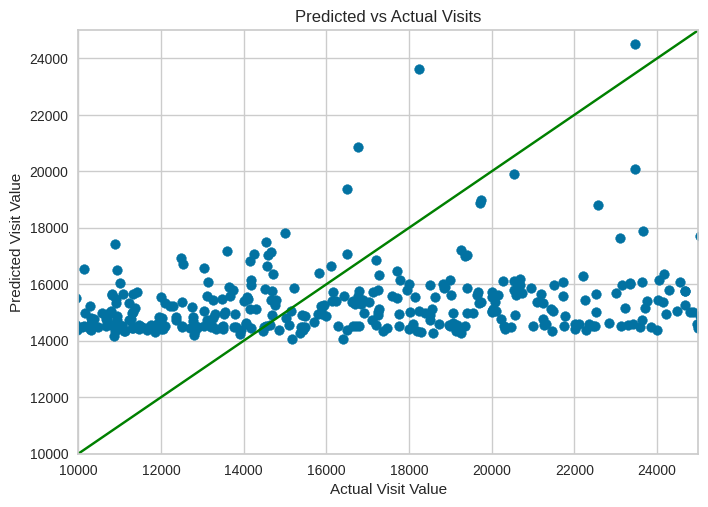

In [1417]:
plt.scatter(results['Actual Visits'], results['Predicted Visits'])
plt.plot([results['Actual Visits'].min(),results['Actual Visits'].max()], [results['Actual Visits'].min(),results['Actual Visits'].max()], color="green")
plt.ylim(10000, 25000)
plt.xlim(10000, 25000)
plt.title("Predicted vs Actual Visits")
plt.xlabel("Actual Visit Value")
plt.ylabel("Predicted Visit Value")
plt.show()

Through this plot we can certainly visualize that this model does not do a great job at predicting visitors. Indicating that these features alone may not predict the number of visitors a library recieves.

Lets look at how large the errors we are recieving are.

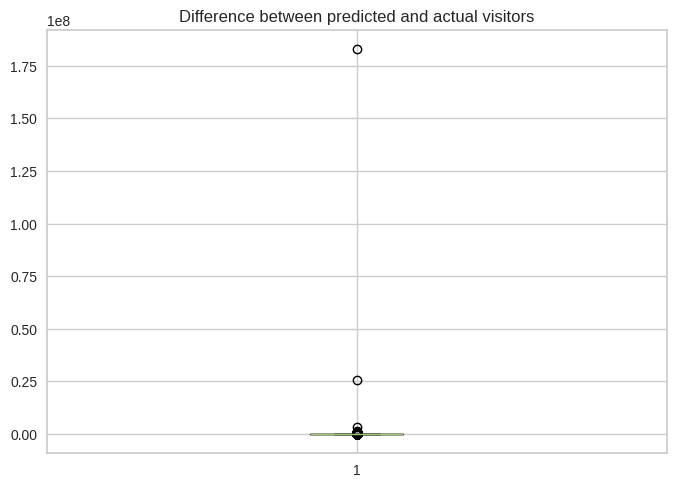

In [1418]:
plt.boxplot(results['Difference in Prediction'])
plt.title("Difference between predicted and actual visitors")
plt.show()

We see that we have an extreme outlier who is really skewing how far off our predicted values were from the actual values. Let's remove some outliers and re-visualize

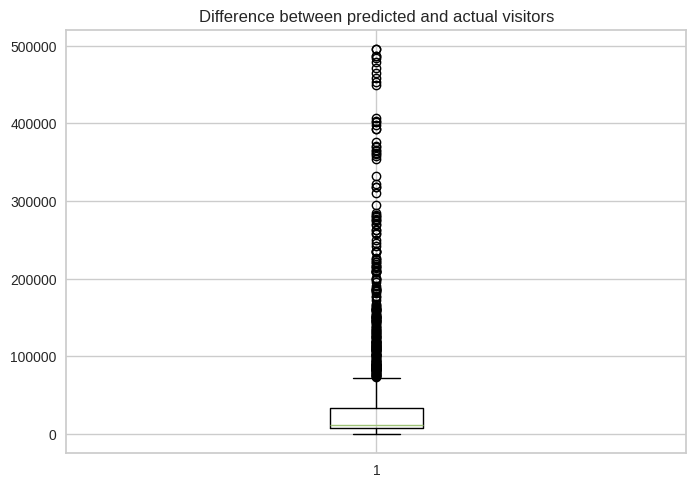

In [1419]:
plt.boxplot(results['Difference in Prediction'][results['Difference in Prediction'] <= 500000])
plt.title("Difference between predicted and actual visitors")
plt.show()

It is clear from this visualization that our model is not very good at predicting the total number of visitors a library recieves based solely on these features. Although we can't use these features to predict visitors accurately, it does give us insight that there are more factors that are important to bringing in visitors! Now, we are going to turn our focus towards trying to determine which features are most related to how many visitors a library recieves.

## Using XGBRegressor to determine which features are most important for predicting the number of visitors

Now, we want to use a machine learning model to learn what features most impact library visitation. We will use the XBGRegressor model to determine this. This can allow us to identify which factors are most important predictors for library visitation, which can help libraries decide where to focus time or resources.

 You can find more information about the XGBRegressor model [here](https://www.geeksforgeeks.org/machine-learning/xgboost-for-regression/)!

 XBGRegressor uses many decision trees

Let's add some features that will help our analysis out.

In [1420]:
library_df['Revenue Per Capita'] = library_df['Total Operating Revenue'] / (library_df['Population of legal service area'])
library_df['Programs Per Capita'] = library_df['Total Number of Live Programs'] / (library_df['Population of legal service area'])
library_df['Books Per Capita'] = library_df['Num. of Print Materials'] / (library_df['Population of legal service area'])

Next, lets define a function for training and testing the model!

In [1421]:
def train_model(data):
  X = data[['Population of legal service area','Total Operating Revenue','Total Librarians','Num. of Print Materials','Num. of Total Physical Items in Collection',
               'Total Number of Live Programs', 'Revenue Per Capita', 'Programs Per Capita', 'Books Per Capita']]
  Y =  data['Visits']

  X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

  model = XGBRegressor(n_estimators=200, learning_rate=0.01,max_depth=5,random_state=42)

  model.fit(X_train, Y_train)

  predictions = model.predict(X_test)

  rmse = np.sqrt(mean_squared_error(Y_test, predictions))
  r2 = r2_score(Y_test, predictions)

  importance = model.feature_importances_

  feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
  }).sort_values(by='Importance', ascending=False)

  return rmse, r2, feature_importance


Now we can run our function on our data!

In [1422]:
rmse, r2, feature_importance = train_model(library_df)
print("RMSE:", rmse)
print("R²:", r2)


RMSE: 83798.76543243343
R²: 0.8152057528495789


We see that 81% of the variablity in the library visits is explained by our model, however, the root mean squared error of 83798 indicates that our predictions are off by about 80,000 visitors each time! This is a really large difference, so we will try our model after removing the top 10% of most visited libraries.  

In [1423]:
rmse, r2, feature_importance_outlier = train_model(library_df[library_df['Visits'] <= library_df['Visits'].quantile(.90)])
print("RMSE:", rmse)
print("R²:", r2)

RMSE: 16711.87649547471
R²: 0.7367449402809143


In [1424]:
library_df[library_df['Visits'] <= library_df['Visits'].quantile(0.90)]['Visits'].mean()

np.float64(28534.977223839047)

Now, we see that the amount our model's error has decreased signifacantly. However, compared to the mean, the error rate is still a little too high to be able to accurately predict the number of visitors. Rather, it can give us a general idea on how these features may impact visitors, but doesn't help us to accurately predict the number of visitors. However, we can use this information in order to determine what the most important features are for determining library visits!

In [1425]:
print("Feature Importance", feature_importance)

Feature Importance                                       Feature  Importance
1                     Total Operating Revenue        0.69
4  Num. of Total Physical Items in Collection        0.07
0            Population of legal service area        0.06
5               Total Number of Live Programs        0.05
7                         Programs Per Capita        0.04
6                          Revenue Per Capita        0.02
3                     Num. of Print Materials        0.02
2                            Total Librarians        0.02
8                            Books Per Capita        0.02


We see that some of the most important feature is the total operating revenue! This makes sense, as libraries with larger budgets can afford to buy more materials or may be able to promote more, thus making them more desirable for users.

## XGBRegressor Visualization

Utilizing the data from our analysis, we will plot library feature importance.

/tmp/ipykernel_11819/2256983889.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


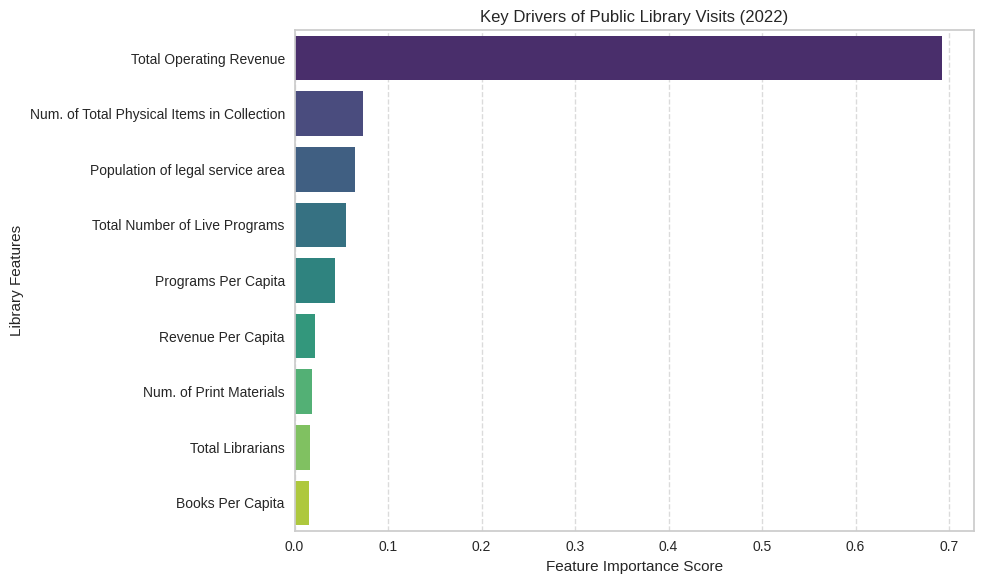

In [1426]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')

plt.title('Key Drivers of Public Library Visits (2022)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Library Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Our visualization shows that the most important feature is the total operating revenue!

## Insights and Conclusions

After cleaning the data, exploring it, and using machine learning algorithms to better understand the data, we can take a step back and look at the results.

From our linear regression model we learned that together the total number of librarians,the operating revenue, the number of items in the collection, and size of the population aren't the main factors that bring in visitors to libraries. This indicates that there are more or different features that may bring in visitors than simply access to funding and resources.

To really get further into what drives library visitation we used the XGBRegressor model. We found that operating revenue was the feature most associated with visits. However, given that our model could not accurately predict the number of visitors a library recieved, we've learned that there are other features not available to us in this dataset that impact the number of visitors a library recieves.

Overall, we have learned that funding is the largest predictor of visitors to libraries, but there may be other key players that aren't captured in this dataset that could be determing visitors.

Here, we have learned that sometimes data on it's own isn't enough to create valuable predictions, however, this doesn't mean we can't learn from the dataset.